<a href="https://colab.research.google.com/github/ahamedcader8055-gtr/NorthStar-Analytics/blob/main/NorthStar_Part_1_SQL_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
install.packages("DBI")
install.packages("RSQLite")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("tidyr")
install.packages("lubridate")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [6]:
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)
library(tidyr)
library(lubridate)

customers   <- read.csv("/customers.csv")
complaints  <- read.csv("/complaints.csv")
app_events  <- read.csv("/app_events.csv")
deliveries  <- read.csv("/deliveries.csv")
drivers     <- read.csv("/drivers.csv")
hubs        <- read.csv("/hubs.csv")
incidents   <- read.csv("/incidents.csv")
orders      <- read.csv("/orders.csv")
vehicles    <- read.csv("/vehicles.csv")
data_dict   <- read.csv("/data_dictionary.csv")

cat("All 10 files loaded successfully!\n")
cat("Orders:", nrow(orders), "rows\n")
cat("Deliveries:", nrow(deliveries), "rows\n")
cat("Customers:", nrow(customers), "rows\n")
cat("Complaints:", nrow(complaints), "rows\n")
cat("Drivers:", nrow(drivers), "rows\n")
cat("Vehicles:", nrow(vehicles), "rows\n")
cat("Incidents:", nrow(incidents), "rows\n")
cat("App Events:", nrow(app_events), "rows\n")
cat("Hubs:", nrow(hubs), "rows\n")
cat("Data Dictionary:", nrow(data_dict), "rows\n")

All 10 files loaded successfully!
Orders: 1250 rows
Deliveries: 950 rows
Customers: 650 rows
Complaints: 320 rows
Drivers: 170 rows
Vehicles: 120 rows
Incidents: 280 rows
App Events: 640 rows
Hubs: 8 rows
Data Dictionary: 9 rows


In [7]:
con <- dbConnect(SQLite(), ":memory:")

dbWriteTable(con, "customers",  customers)
dbWriteTable(con, "complaints", complaints)
dbWriteTable(con, "app_events", app_events)
dbWriteTable(con, "deliveries", deliveries)
dbWriteTable(con, "drivers",    drivers)
dbWriteTable(con, "hubs",       hubs)
dbWriteTable(con, "incidents",  incidents)
dbWriteTable(con, "orders",     orders)
dbWriteTable(con, "vehicles",   vehicles)
dbWriteTable(con, "data_dict",  data_dict)

cat("SQL database ready!\n")
cat("Tables loaded:", paste(dbListTables(con), collapse=", "), "\n")

SQL database ready!
Tables loaded: app_events, complaints, customers, data_dict, deliveries, drivers, hubs, incidents, orders, vehicles 


  delivery_status total percentage avg_rating avg_cost avg_distance_km
1          OnTime   616      64.84       4.28    12.68           13.78
2         Delayed   202      21.26       3.11    13.14           14.67
3          Failed   132      13.89       3.05    13.15           13.37


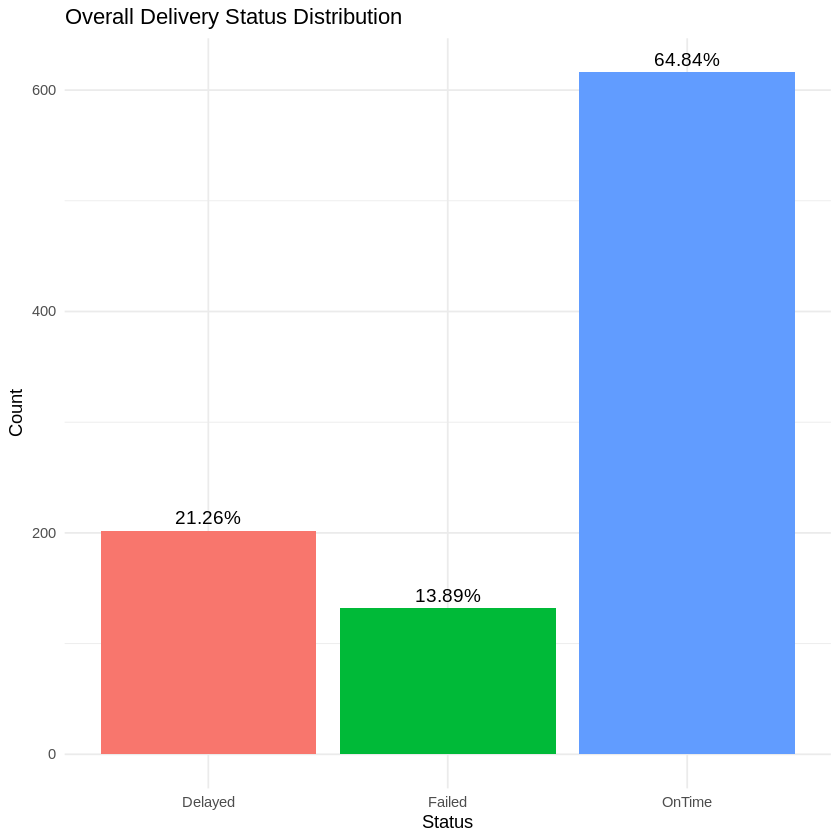

In [8]:
q1 <- dbGetQuery(con, "
  SELECT
    delivery_status,
    COUNT(*)                                    AS total,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*))
          OVER(), 2)                            AS percentage,
    ROUND(AVG(customer_rating_post_delivery),2) AS avg_rating,
    ROUND(AVG(fuel_or_charge_cost), 2)          AS avg_cost,
    ROUND(AVG(route_distance_km), 2)            AS avg_distance_km
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total DESC
")
print(q1)

ggplot(q1, aes(x=delivery_status, y=total, fill=delivery_status)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=paste0(percentage,"%")), vjust=-0.5, size=4) +
  labs(title="Overall Delivery Status Distribution",
       x="Status", y="Count") +
  theme_minimal() +
  theme(legend.position="none")

        hub_name      zone  hub_type capacity_score total_deliveries failed
1  Midtown Relay   Central  Charging             63              128     26
2   Central Core   Central   Control             88              115     23
3 North Exchange     North  Dispatch             82              136     17
4      West Gate      West  Dispatch             69              127     16
5    Airport Hub   Airport  Dispatch             71              104     15
6  Riverside Hub Riverside Warehouse             66              115     14
7      East Dock      East Warehouse             74              119     11
8     South Link     South  Dispatch             78              106     10
  delayed on_time avg_rating avg_cost total_overrides missing_proofs
1      22      80       3.88    11.71             142             10
2      25      67       3.67    13.69             109             10
3      26      93       3.84    12.76             140              6
4      28      83       3.92    13.17   

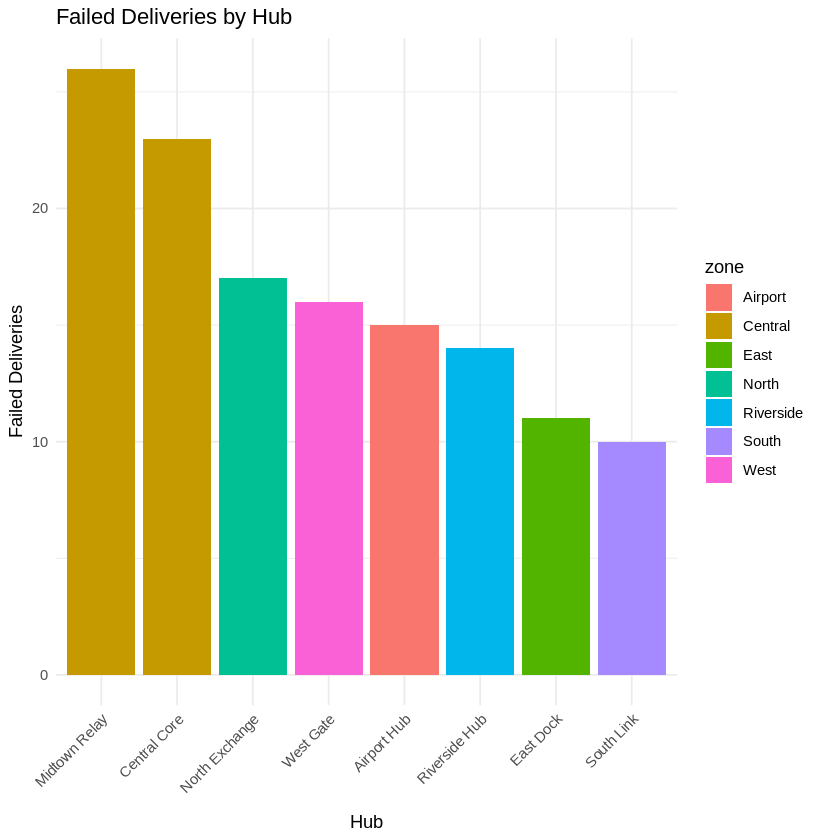

In [9]:
q2 <- dbGetQuery(con, "
  SELECT
    h.hub_name,
    h.zone,
    h.hub_type,
    h.capacity_score,
    COUNT(d.delivery_id)                                           AS total_deliveries,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END)  AS delayed,
    SUM(CASE WHEN d.delivery_status='OnTime'  THEN 1 ELSE 0 END)  AS on_time,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                 AS avg_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                           AS avg_cost,
    SUM(d.manual_route_override_count)                             AS total_overrides,
    SUM(d.proof_of_completion_missing)                             AS missing_proofs
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_name, h.zone, h.hub_type, h.capacity_score
  ORDER BY failed DESC
")
print(q2)

ggplot(q2, aes(x=reorder(hub_name, -failed), y=failed, fill=zone)) +
  geom_bar(stat="identity") +
  labs(title="Failed Deliveries by Hub",
       x="Hub", y="Failed Deliveries") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1))

  service_type total failed delayed on_time avg_rating avg_cost avg_order_value
1    Passenger   262     38      53     171       3.85    12.40           97.19
2       Retail   224     28      50     146       3.87    12.97           86.81
3       Parcel   230     25      49     156       3.90    13.08           90.15
4     Business   126     25      28      73       3.85    13.14           97.45
5      Medical   108     16      22      70       3.84    12.77           86.53
  total_overrides
1             228
2             210
3             244
4             148
5              91


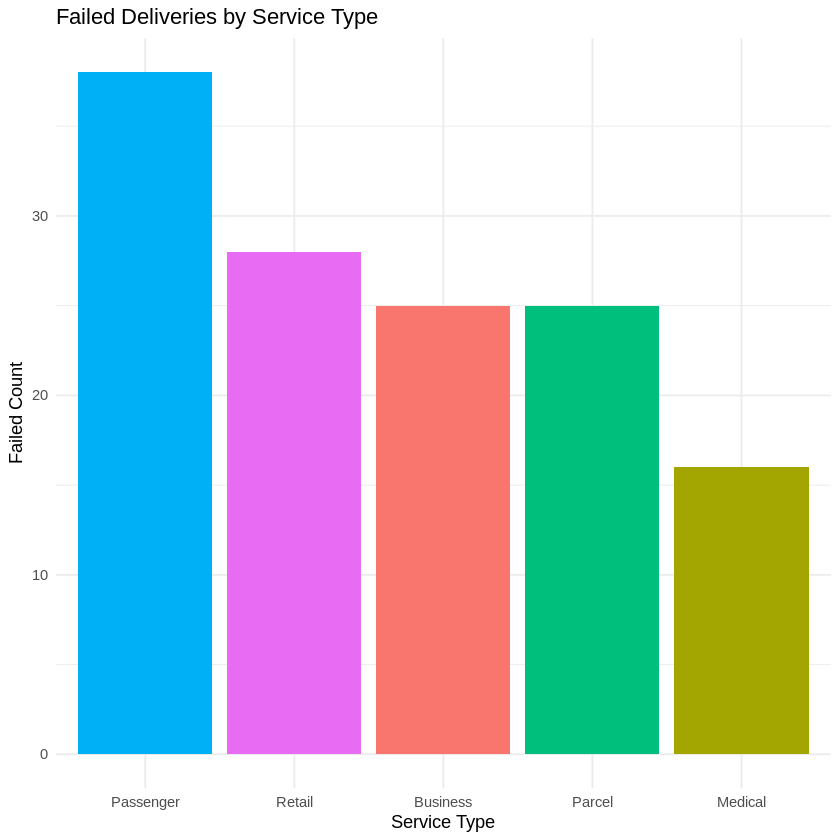

In [10]:
q3 <- dbGetQuery(con, "
  SELECT
    o.service_type,
    COUNT(d.delivery_id)                                           AS total,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END)  AS delayed,
    SUM(CASE WHEN d.delivery_status='OnTime'  THEN 1 ELSE 0 END)  AS on_time,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                 AS avg_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                           AS avg_cost,
    ROUND(AVG(o.order_value), 2)                                   AS avg_order_value,
    SUM(d.manual_route_override_count)                             AS total_overrides
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY failed DESC
")
print(q3)

ggplot(q3, aes(x=reorder(service_type, -failed), y=failed, fill=service_type)) +
  geom_bar(stat="identity") +
  labs(title="Failed Deliveries by Service Type",
       x="Service Type", y="Failed Count") +
  theme_minimal() +
  theme(legend.position="none")

       zone total_deliveries failed delayed on_time avg_rating avg_cost
1     NORTH              135     22      21      92       3.90    12.07
2   CENTRAL              110     22      27      61       3.62    12.15
3      EAST              156     19      31     106       3.91    12.57
4 RIVERSIDE              119     18      25      76       3.86    12.39
5      WEST              114     14      21      79       3.90    11.94
6     SOUTH              139     14      22     103       4.05    12.48
7   AIRPORT              113     12      31      70       3.98    17.08
8       CTR               64     11      24      29       3.43    12.07
  total_overrides
1              94
2             178
3             123
4              87
5              92
6              96
7             204
8              47


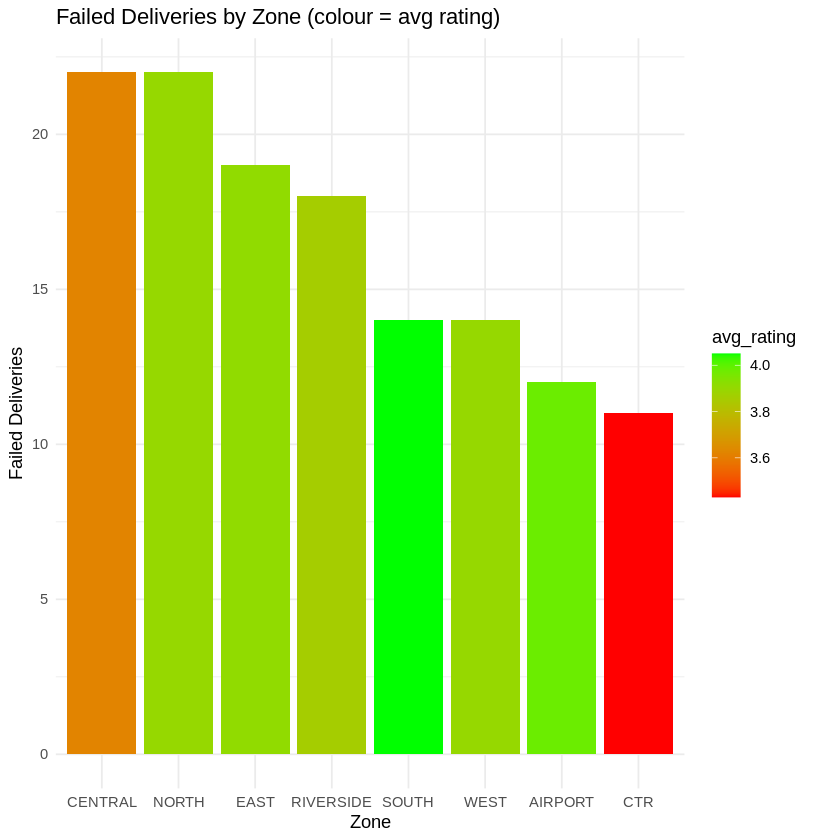

In [11]:
q4 <- dbGetQuery(con, "
  SELECT
    UPPER(o.pickup_zone)                                           AS zone,
    COUNT(d.delivery_id)                                           AS total_deliveries,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END)  AS delayed,
    SUM(CASE WHEN d.delivery_status='OnTime'  THEN 1 ELSE 0 END)  AS on_time,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                 AS avg_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                           AS avg_cost,
    SUM(d.manual_route_override_count)                             AS total_overrides
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY UPPER(o.pickup_zone)
  ORDER BY failed DESC
")
print(q4)

ggplot(q4, aes(x=reorder(zone, -failed), y=failed, fill=avg_rating)) +
  geom_bar(stat="identity") +
  scale_fill_gradient(low="red", high="green") +
  labs(title="Failed Deliveries by Zone (colour = avg rating)",
       x="Zone", y="Failed Deliveries") +
  theme_minimal()

  employment_type num_drivers total_deliveries failed delayed on_time
1        FullTime         110              582     85     121     376
2        PartTime          40              242     29      55     158
3        Contract          20              126     18      26      82
  avg_training_score avg_driver_rating avg_overrides avg_fuel_cost
1              75.33              4.16          1.02         12.90
2              73.42              4.20          0.86         12.87
3              73.38              4.12          0.93         12.52


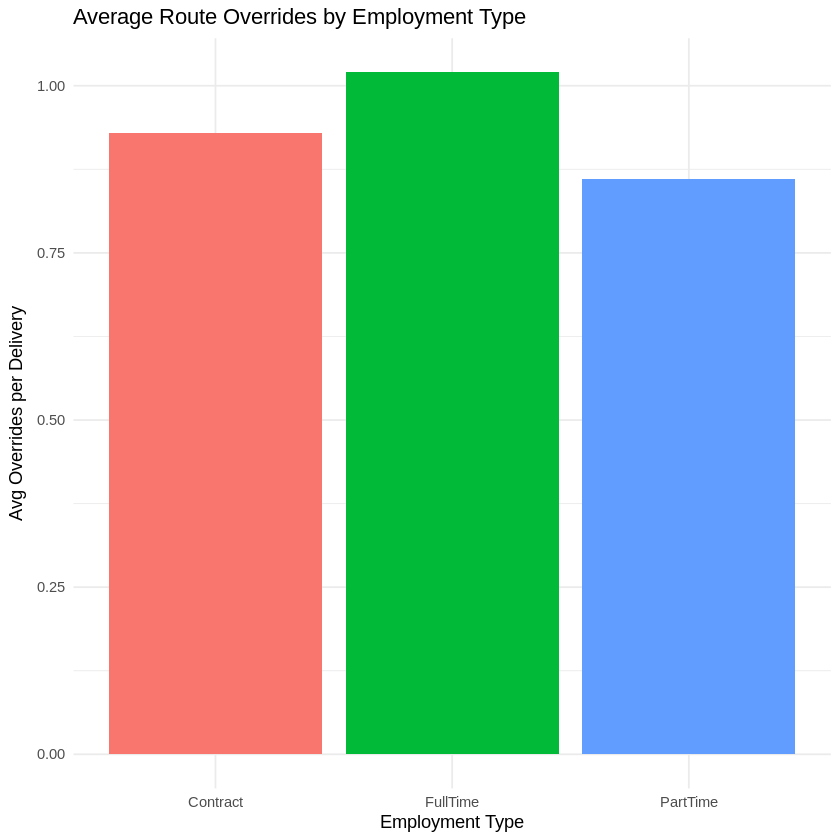

In [12]:
q5 <- dbGetQuery(con, "
  SELECT
    dr.employment_type,
    COUNT(DISTINCT dr.driver_id)                                   AS num_drivers,
    COUNT(d.delivery_id)                                           AS total_deliveries,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END)  AS delayed,
    SUM(CASE WHEN d.delivery_status='OnTime'  THEN 1 ELSE 0 END)  AS on_time,
    ROUND(AVG(dr.training_score), 2)                               AS avg_training_score,
    ROUND(AVG(dr.driver_rating), 2)                                AS avg_driver_rating,
    ROUND(AVG(d.manual_route_override_count), 2)                   AS avg_overrides,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                           AS avg_fuel_cost
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY dr.employment_type
  ORDER BY failed DESC
")
print(q5)

ggplot(q5, aes(x=employment_type, y=avg_overrides, fill=employment_type)) +
  geom_bar(stat="identity") +
  labs(title="Average Route Overrides by Employment Type",
       x="Employment Type", y="Avg Overrides per Delivery") +
  theme_minimal() +
  theme(legend.position="none")

   driver_id training_score driver_rating years_experience employment_type
1       D001           67.8          3.54                8        FullTime
2       D002           42.4          3.94                4        FullTime
3       D003           96.5          5.00               11        FullTime
4       D004           88.9          4.75               13        PartTime
5       D005           69.7          4.14                3        FullTime
6       D006           78.8          4.38                8        FullTime
7       D007           92.6          3.94                4        FullTime
8       D008           84.1          3.88                9        FullTime
9       D009           63.4          3.80               15        FullTime
10      D010           70.0          3.95                8        FullTime
   total_deliveries failed on_time avg_overrides
1                 6      1       4          0.67
2                 7      1       4          1.00
3                 4      0  

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


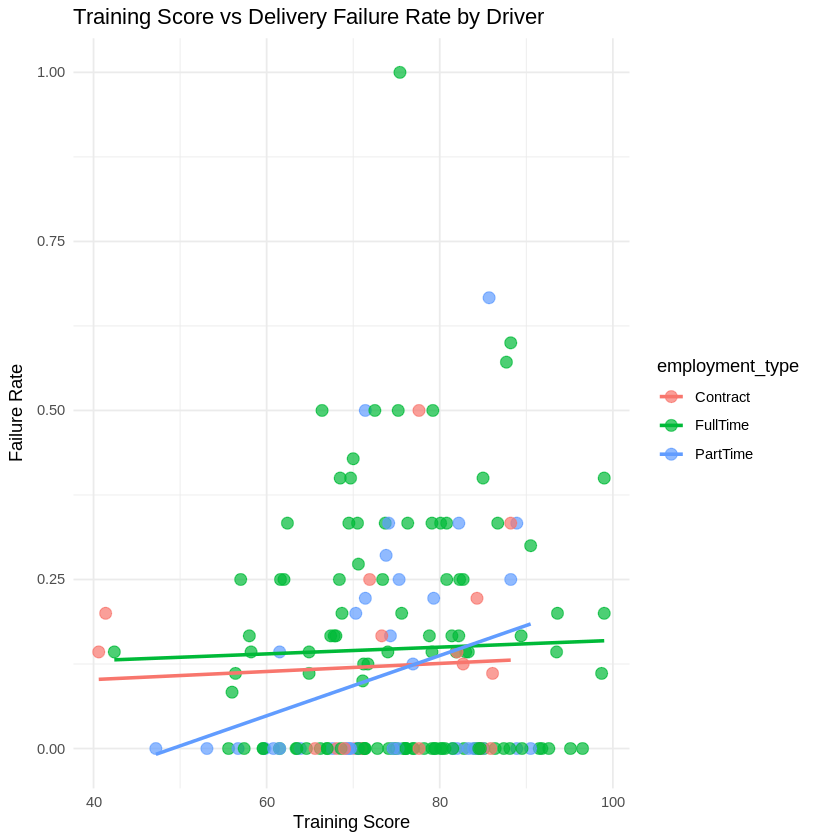

In [13]:
q6 <- dbGetQuery(con, "
  SELECT
    dr.driver_id,
    dr.training_score,
    dr.driver_rating,
    dr.years_experience,
    dr.employment_type,
    COUNT(d.delivery_id)                                           AS total_deliveries,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status='OnTime'  THEN 1 ELSE 0 END)  AS on_time,
    ROUND(AVG(d.manual_route_override_count), 2)                   AS avg_overrides
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY dr.driver_id, dr.training_score, dr.driver_rating,
           dr.years_experience, dr.employment_type
")
print(head(q6, 10))

# Calculate failure rate and visualise
q6$failure_rate <- q6$failed / q6$total_deliveries
ggplot(q6, aes(x=training_score, y=failure_rate, color=employment_type)) +
  geom_point(size=3, alpha=0.7) +
  geom_smooth(method="lm", se=FALSE) +
  labs(title="Training Score vs Delivery Failure Rate by Driver",
       x="Training Score", y="Failure Rate") +
  theme_minimal()

   driver_id base_zone employment_type training_score total_overrides
1       D127   CENTRAL        FullTime           61.5              17
2       D087     north        Contract           73.3              16
3       D130      WEST        FullTime           71.2              16
4       D108     South        FullTime           70.6              15
5       D131     SOUTH        FullTime           86.7              15
6       D069     NORTH        PartTime           61.5              14
7       D105 RiverSide        Contract           82.0              14
8       D017      EAST        PartTime             NA              13
9       D028     North        FullTime           83.0              13
10      D008     SOUTH        FullTime           84.1              12
11      D026     NORTH        PartTime           84.9              12
12      D104      WEST        FullTime           87.7              12
13      D027   AIRPORT        PartTime           74.3              11
14      D033     Sou

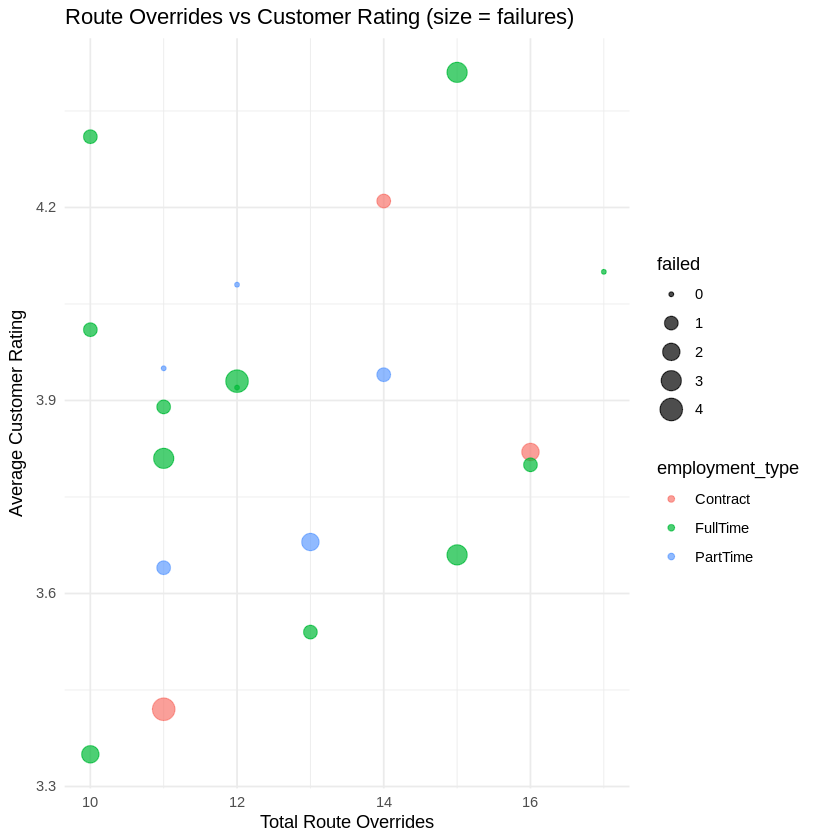

In [14]:
q7 <- dbGetQuery(con, "
  SELECT
    dr.driver_id,
    dr.base_zone,
    dr.employment_type,
    dr.training_score,
    SUM(d.manual_route_override_count)                             AS total_overrides,
    COUNT(d.delivery_id)                                           AS total_deliveries,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END)  AS delayed,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                 AS avg_rating
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY dr.driver_id, dr.base_zone,
           dr.employment_type, dr.training_score
  HAVING total_overrides > 0
  ORDER BY total_overrides DESC
  LIMIT 20
")
print(q7)

ggplot(q7, aes(x=total_overrides, y=avg_rating,
               color=employment_type, size=failed)) +
  geom_point(alpha=0.7) +
  labs(title="Route Overrides vs Customer Rating (size = failures)",
       x="Total Route Overrides", y="Average Customer Rating") +
  theme_minimal()

   vehicle_type maintenance_status total_deliveries failed delayed on_time
1      CargoVan           InRepair               68     22      16      30
2        Hybrid           InRepair               71     21      11      39
3        Diesel           InRepair               55     17      11      27
4            EV           InRepair               60     17      14      29
5        Hybrid             Active              131     15      25      91
6      CargoVan             Active              117     11      29      77
7            EV             Active              214     11      48     155
8        Diesel             Active               80      8      11      61
9      CargoVan          Scheduled               38      5       8      25
10           EV          Scheduled               65      2      12      51
11       Hybrid          Scheduled               42      2      16      24
12       Diesel          Scheduled                9      1       1       7
   avg_battery_health avg

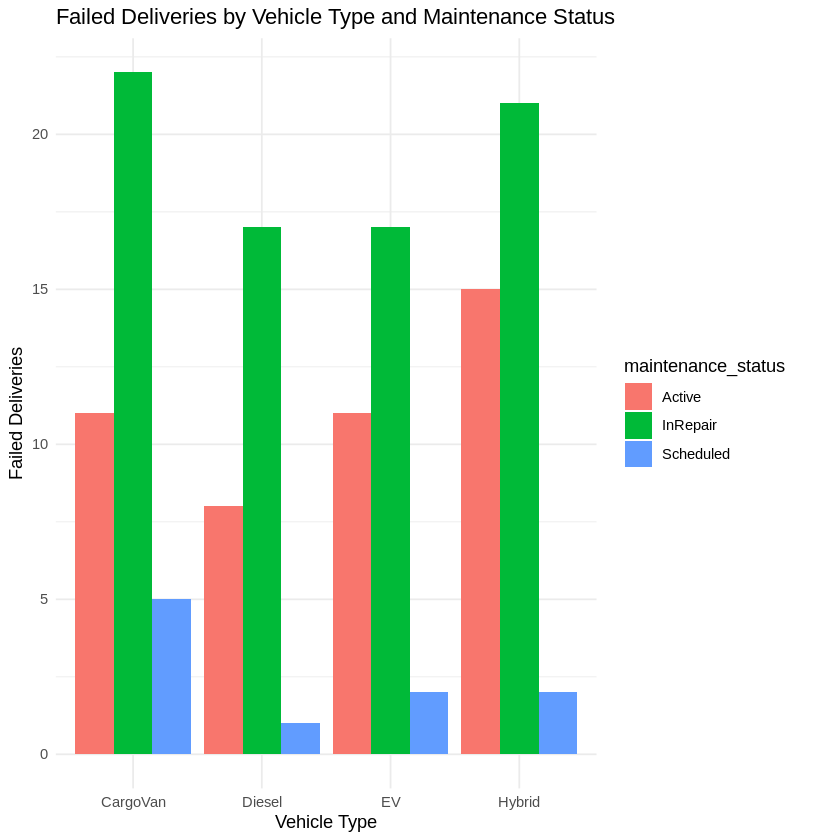

In [15]:
q8 <- dbGetQuery(con, "
  SELECT
    v.vehicle_type,
    v.maintenance_status,
    COUNT(d.delivery_id)                                           AS total_deliveries,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status='Delayed' THEN 1 ELSE 0 END)  AS delayed,
    SUM(CASE WHEN d.delivery_status='OnTime'  THEN 1 ELSE 0 END)  AS on_time,
    ROUND(AVG(v.battery_health_pct), 2)                            AS avg_battery_health,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                           AS avg_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                 AS avg_rating
  FROM deliveries d
  JOIN vehicles v ON d.vehicle_id = v.vehicle_id
  GROUP BY v.vehicle_type, v.maintenance_status
  ORDER BY failed DESC
")
print(q8)

ggplot(q8, aes(x=vehicle_type, y=failed, fill=maintenance_status)) +
  geom_bar(stat="identity", position="dodge") +
  labs(title="Failed Deliveries by Vehicle Type and Maintenance Status",
       x="Vehicle Type", y="Failed Deliveries") +
  theme_minimal()

   vehicle_id vehicle_type battery_health_pct maintenance_status odometer_km
1        V047           EV               93.7          Scheduled      134347
2        V108       Diesel               54.6           InRepair      141290
3        V030     CargoVan               78.0             Active      134360
4        V046           EV               95.8             Active      101425
5        V097           EV               92.1             Active       18680
6        V005     CargoVan               58.6             Active      146638
7        V009     CargoVan               68.8             Active      156687
8        V035     CargoVan               83.6             Active       73804
9        V042           EV               80.5           InRepair      215870
10       V076       Diesel               65.8           InRepair      106063
11       V088       Diesel               80.3           InRepair       50427
12       V001           EV               71.8             Active       56928

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


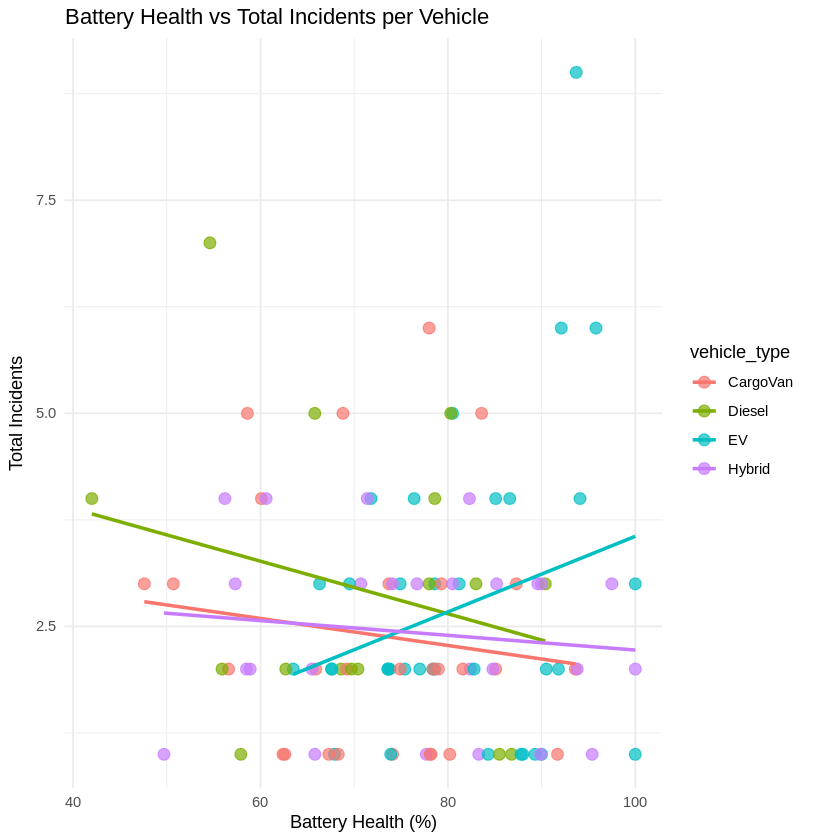

In [16]:
q9 <- dbGetQuery(con, "
  SELECT
    v.vehicle_id,
    v.vehicle_type,
    v.battery_health_pct,
    v.maintenance_status,
    v.odometer_km,
    COUNT(i.incident_id)                                                AS total_incidents,
    SUM(CASE WHEN i.incident_type='BatteryAlert'    THEN 1 ELSE 0 END) AS battery_alerts,
    SUM(CASE WHEN i.incident_type='VehicleFault'    THEN 1 ELSE 0 END) AS vehicle_faults,
    SUM(CASE WHEN i.severity='Critical'             THEN 1 ELSE 0 END) AS critical_incidents,
    ROUND(AVG(i.resolved_hours), 2)                                     AS avg_resolve_hours
  FROM vehicles v
  JOIN deliveries d  ON v.vehicle_id  = d.vehicle_id
  JOIN incidents  i  ON d.delivery_id = i.delivery_id
  GROUP BY v.vehicle_id, v.vehicle_type,
           v.battery_health_pct, v.maintenance_status, v.odometer_km
  ORDER BY total_incidents DESC
")
print(head(q9, 15))

ggplot(q9, aes(x=battery_health_pct, y=total_incidents, color=vehicle_type)) +
  geom_point(size=3, alpha=0.7) +
  geom_smooth(method="lm", se=FALSE) +
  labs(title="Battery Health vs Total Incidents per Vehicle",
       x="Battery Health (%)", y="Total Incidents") +
  theme_minimal()

      incident_type resolution_status total avg_resolve_hours min_hours
1    RouteDeviation         Escalated     5             18.60      11.6
2      BatteryAlert         Escalated     5             18.46      12.3
3  TemperatureIssue              Open     3             18.33      12.9
4      VehicleFault         Escalated     2             16.00      10.8
5    RouteDeviation              Open    15             14.95       3.2
6    CustomerNoShow     PendingVendor     7             14.43       7.2
7    SafetyNearMiss              Open     3             14.43       6.5
8      AppSyncError              Open     7             14.19       2.1
9    CustomerNoShow            Closed    21             14.04       0.2
10     ProofMissing              Open    12             13.87       1.1
11     AppSyncError     PendingVendor    10             13.72       4.8
12   RouteDeviation            Closed    18             13.68       2.2
13   CustomerNoShow              Open    12             13.65   

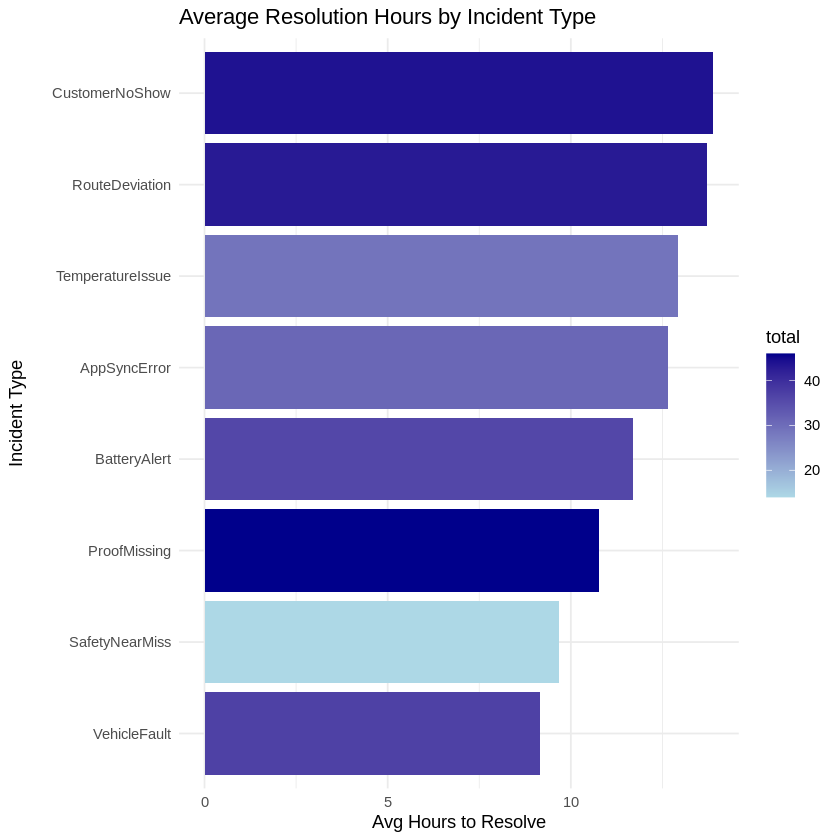

In [17]:
q10 <- dbGetQuery(con, "
  SELECT
    incident_type,
    resolution_status,
    COUNT(*)                              AS total,
    ROUND(AVG(resolved_hours), 2)         AS avg_resolve_hours,
    ROUND(MIN(resolved_hours), 2)         AS min_hours,
    ROUND(MAX(resolved_hours), 2)         AS max_hours,
    SUM(CASE WHEN severity='Critical'
             THEN 1 ELSE 0 END)           AS critical_count,
    SUM(CASE WHEN severity='High'
             THEN 1 ELSE 0 END)           AS high_count
  FROM incidents
  GROUP BY incident_type, resolution_status
  ORDER BY avg_resolve_hours DESC
")
print(q10)

q10_summary <- dbGetQuery(con, "
  SELECT incident_type,
         ROUND(AVG(resolved_hours),2) AS avg_hours,
         COUNT(*) AS total
  FROM incidents
  GROUP BY incident_type
  ORDER BY avg_hours DESC
")
ggplot(q10_summary, aes(x=reorder(incident_type, avg_hours),
                        y=avg_hours, fill=total)) +
  geom_bar(stat="identity") +
  coord_flip() +
  scale_fill_gradient(low="lightblue", high="darkblue") +
  labs(title="Average Resolution Hours by Incident Type",
       x="Incident Type", y="Avg Hours to Resolve") +
  theme_minimal()

      complaint_type severity total avg_resolution_days avg_compensation
1              Delay   Medium    56                5.96            18.21
2       MissedPickup   Medium    37                6.16            17.91
3    DriverBehaviour   Medium    31                5.42            15.88
4              Delay      Low    27                6.48             8.16
5           AppIssue   Medium    25                7.36            16.11
6              Delay     High    18               12.44            36.54
7    DriverBehaviour     High    16               13.75            38.39
8       MissedPickup     High    16               11.56            43.07
9           AppIssue      Low    15                6.07            13.25
10          AppIssue     High    13               13.92            34.05
11 SupportExperience   Medium    12                6.17            18.68
12      MissedPickup      Low    11                6.91             8.14
13           Billing   Medium     9                

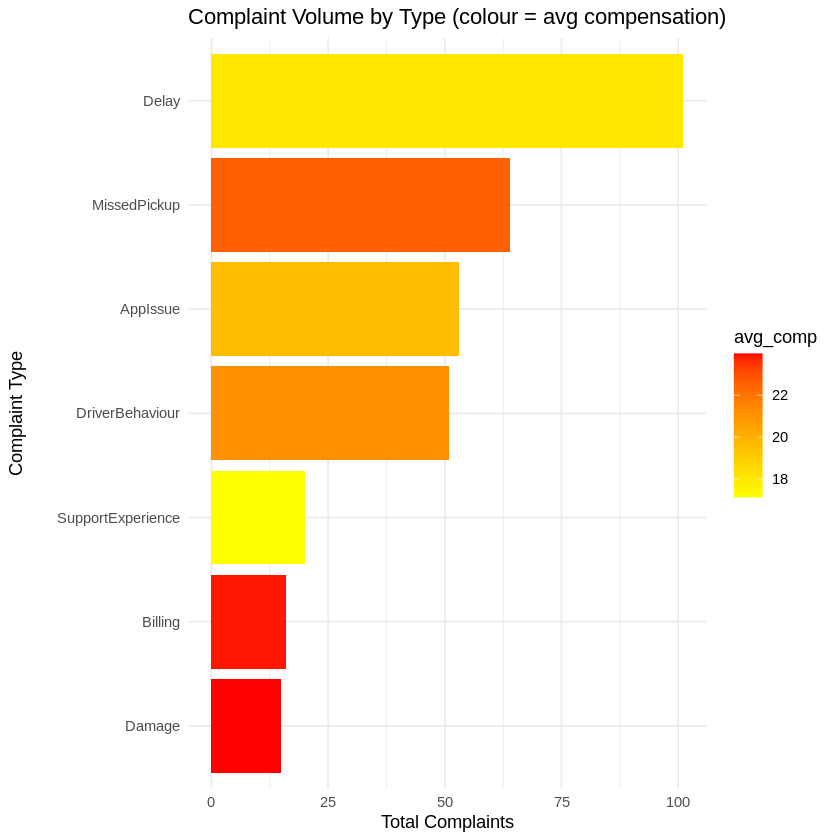

In [18]:
q11 <- dbGetQuery(con, "
  SELECT
    complaint_type,
    severity,
    COUNT(*)                                  AS total,
    ROUND(AVG(resolution_days), 2)            AS avg_resolution_days,
    ROUND(AVG(compensation_amount), 2)        AS avg_compensation,
    SUM(CASE WHEN status='Escalated'
             THEN 1 ELSE 0 END)               AS escalated_count,
    SUM(CASE WHEN status='Open'
             THEN 1 ELSE 0 END)               AS still_open
  FROM complaints
  GROUP BY complaint_type, severity
  ORDER BY total DESC
")
print(q11)

q11_type <- dbGetQuery(con, "
  SELECT complaint_type, COUNT(*) AS total,
         ROUND(AVG(compensation_amount),2) AS avg_comp
  FROM complaints GROUP BY complaint_type ORDER BY total DESC
")
ggplot(q11_type, aes(x=reorder(complaint_type, total),
                     y=total, fill=avg_comp)) +
  geom_bar(stat="identity") +
  coord_flip() +
  scale_fill_gradient(low="yellow", high="red") +
  labs(title="Complaint Volume by Type (colour = avg compensation)",
       x="Complaint Type", y="Total Complaints") +
  theme_minimal()

  customer_type account_status total_customers total_complaints
1    Enterprise        Dormant               6                7
2    Enterprise      Suspended               2                2
3           SME      Suspended               5                3
4      Consumer         Active             406              214
5      Consumer      Suspended              13                6
6    Enterprise         Active              42               19
7           SME         Active             104               43
8      Consumer        Dormant              57               22
9           SME        Dormant              15                4
  complaints_per_customer avg_resolution_days avg_compensation
1                    1.17                8.29            19.35
2                    1.00                9.50             9.37
3                    0.60                4.67            19.39
4                    0.53                7.79            20.33
5                    0.46                9.33

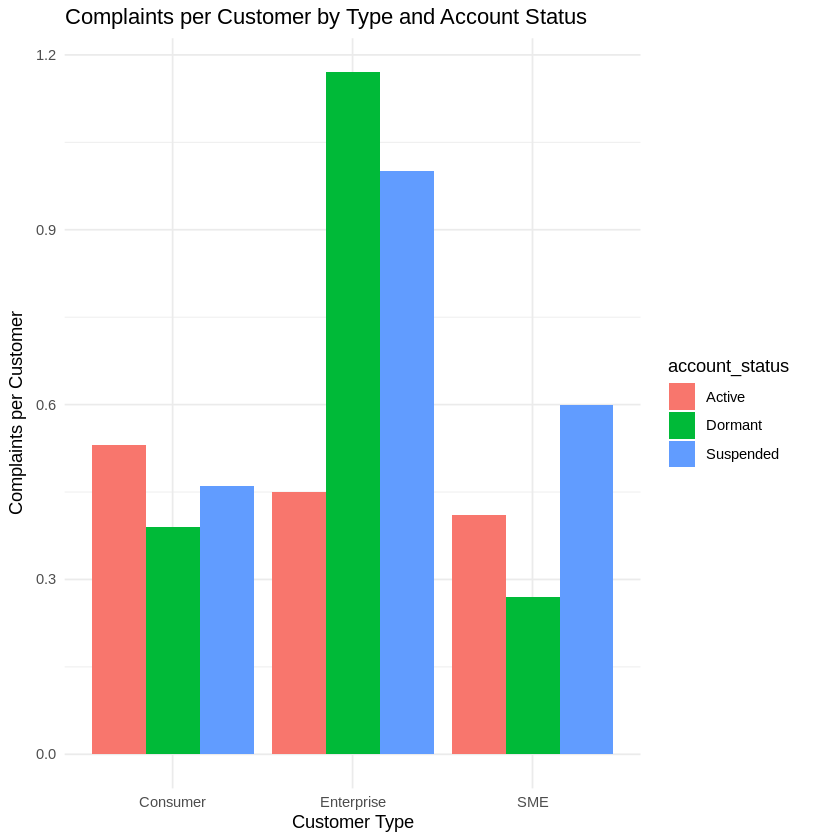

In [19]:
q12 <- dbGetQuery(con, "
  SELECT
    c.customer_type,
    c.account_status,
    COUNT(DISTINCT c.customer_id)             AS total_customers,
    COUNT(cp.complaint_id)                    AS total_complaints,
    ROUND(COUNT(cp.complaint_id) * 1.0 /
          COUNT(DISTINCT c.customer_id), 2)   AS complaints_per_customer,
    ROUND(AVG(cp.resolution_days), 2)         AS avg_resolution_days,
    ROUND(AVG(cp.compensation_amount), 2)     AS avg_compensation,
    ROUND(AVG(c.loyalty_score), 2)            AS avg_loyalty_score
  FROM customers c
  LEFT JOIN complaints cp ON c.customer_id = cp.customer_id
  GROUP BY c.customer_type, c.account_status
  ORDER BY complaints_per_customer DESC
")
print(q12)

ggplot(q12, aes(x=customer_type, y=complaints_per_customer,
                fill=account_status)) +
  geom_bar(stat="identity", position="dodge") +
  labs(title="Complaints per Customer by Type and Account Status",
       x="Customer Type", y="Complaints per Customer") +
  theme_minimal()

   customer_id loyalty_score app_engagement_score customer_type home_zone
1        C0001          44.9                 69.2           SME     North
2        C0002          55.4                 66.6      Consumer   AIRPORT
3        C0003          75.9                 33.8      Consumer      East
4        C0004          32.5                 33.0      Consumer   CENTRAL
5        C0005          55.9                100.0      Consumer Riverside
6        C0006          39.9                 43.3      Consumer      WEST
7        C0007          36.1                 39.0      Consumer      WEST
8        C0008          84.6                 65.2           SME     north
9        C0009          62.6                 40.8      Consumer     South
10       C0010          87.2                 48.6      Consumer      West
   complaint_count avg_compensation
1                2            21.95
2                0               NA
3                0               NA
4                2            17.79
5     

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


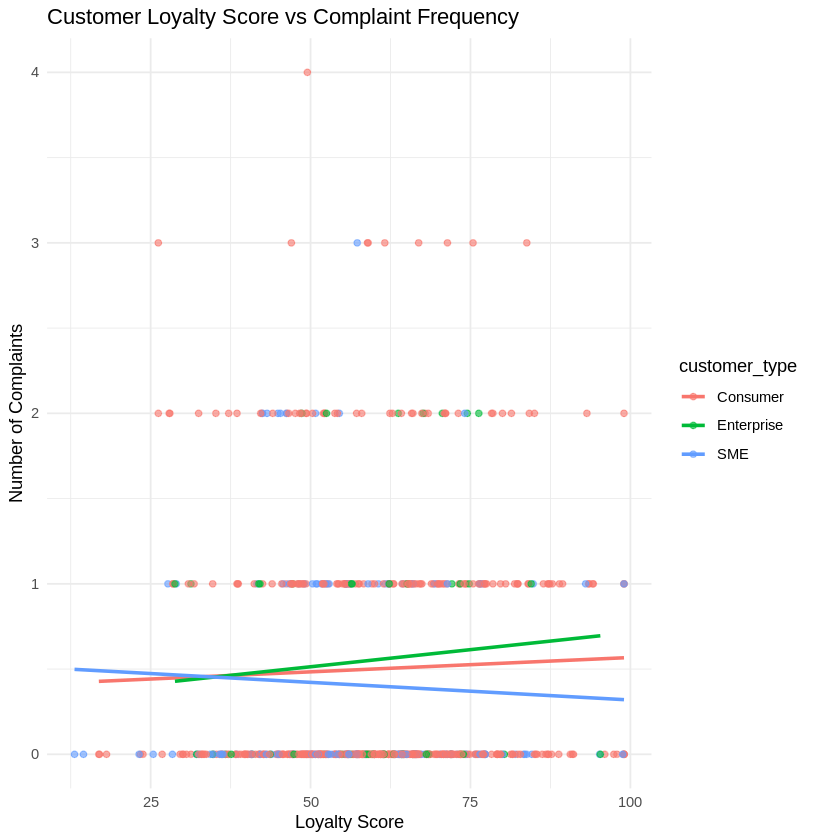

In [20]:
q13 <- dbGetQuery(con, "
  SELECT
    c.customer_id,
    c.loyalty_score,
    c.app_engagement_score,
    c.customer_type,
    c.home_zone,
    COUNT(cp.complaint_id)                    AS complaint_count,
    ROUND(AVG(cp.compensation_amount), 2)     AS avg_compensation
  FROM customers c
  LEFT JOIN complaints cp ON c.customer_id = cp.customer_id
  GROUP BY c.customer_id, c.loyalty_score, c.app_engagement_score,
           c.customer_type, c.home_zone
")
print(head(q13, 10))

ggplot(q13, aes(x=loyalty_score, y=complaint_count, color=customer_type)) +
  geom_point(alpha=0.6) +
  geom_smooth(method="lm", se=FALSE) +
  labs(title="Customer Loyalty Score vs Complaint Frequency",
       x="Loyalty Score", y="Number of Complaints") +
  theme_minimal()

   service_type      zone total_deliveries total_cost avg_cost_per_delivery
1       Medical       CTR                2      22.27                 11.13
2      Business      WEST               12     158.61                 13.22
3      Business   AIRPORT               13     244.10                 18.78
4       Medical   AIRPORT               10     163.95                 16.39
5       Medical   CENTRAL               11     144.34                 13.12
6     Passenger       CTR               13     139.28                 10.71
7       Medical     NORTH               18     222.47                 12.36
8       Medical      EAST               19     245.51                 12.92
9       Medical      WEST               17     191.34                 11.26
10     Business   CENTRAL               12     122.70                 10.22
11      Medical RIVERSIDE               14     181.72                 12.98
12       Parcel       CTR               15     174.25                 11.62
13     Busin

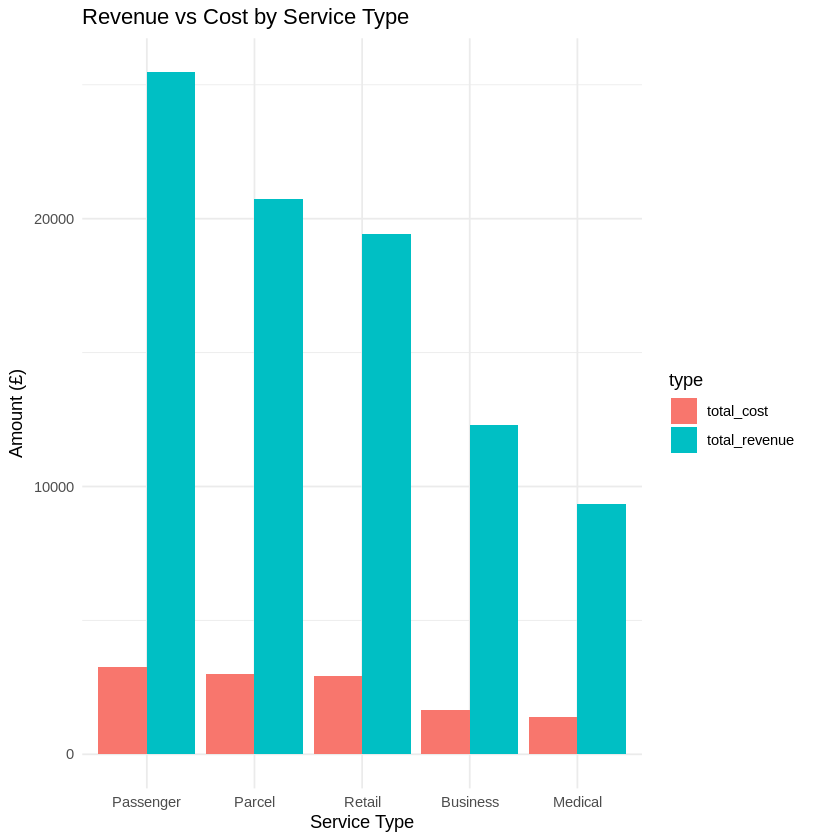

In [21]:
q14 <- dbGetQuery(con, "
  SELECT
    o.service_type,
    UPPER(o.pickup_zone)                      AS zone,
    COUNT(d.delivery_id)                      AS total_deliveries,
    ROUND(SUM(d.fuel_or_charge_cost), 2)      AS total_cost,
    ROUND(AVG(d.fuel_or_charge_cost), 2)      AS avg_cost_per_delivery,
    ROUND(SUM(o.order_value), 2)              AS total_revenue,
    ROUND(AVG(o.order_value), 2)              AS avg_order_value,
    ROUND(SUM(o.order_value) -
          SUM(d.fuel_or_charge_cost), 2)      AS net_margin
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type, UPPER(o.pickup_zone)
  ORDER BY net_margin ASC
")
print(q14)

q14_service <- dbGetQuery(con, "
  SELECT o.service_type,
    ROUND(SUM(o.order_value),2) AS total_revenue,
    ROUND(SUM(d.fuel_or_charge_cost),2) AS total_cost,
    ROUND(SUM(o.order_value)-SUM(d.fuel_or_charge_cost),2) AS net_margin
  FROM deliveries d JOIN orders o ON d.order_id=o.order_id
  GROUP BY o.service_type ORDER BY net_margin ASC
")
q14_long <- tidyr::pivot_longer(q14_service,
             cols=c(total_revenue, total_cost),
             names_to="type", values_to="amount")
ggplot(q14_long, aes(x=reorder(service_type, -amount),
                     y=amount, fill=type)) +
  geom_bar(stat="identity", position="dodge") +
  labs(title="Revenue vs Cost by Service Type",
       x="Service Type", y="Amount (£)") +
  theme_minimal()

  priority_level total failed on_time avg_rating avg_cost avg_order_value
1       Critical    74      3      56       4.10    11.32           87.57
2           High   231     32     153       3.85    12.71           95.36
3         Medium   386     63     235       3.79    13.20           93.13
4            Low   259     34     172       3.93    12.85           88.08
  total_overrides
1              59
2             223
3             391
4             248


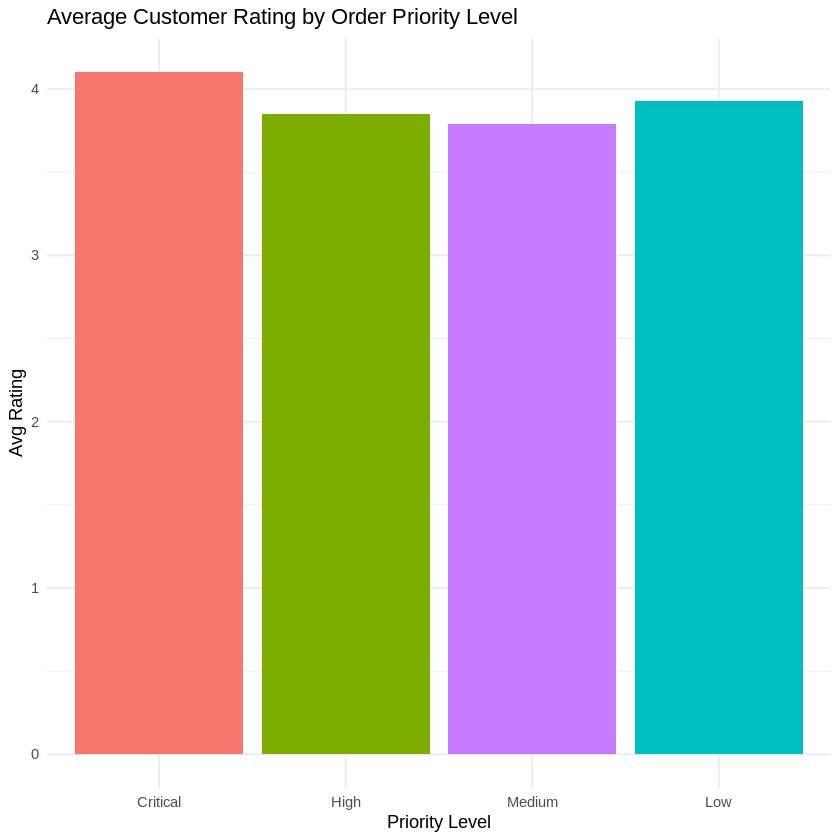

In [22]:
q15 <- dbGetQuery(con, "
  SELECT
    o.priority_level,
    COUNT(d.delivery_id)                                           AS total,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status='OnTime'  THEN 1 ELSE 0 END)  AS on_time,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                 AS avg_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                           AS avg_cost,
    ROUND(AVG(o.order_value), 2)                                   AS avg_order_value,
    SUM(d.manual_route_override_count)                             AS total_overrides
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.priority_level
  ORDER BY CASE o.priority_level
           WHEN 'Critical' THEN 1 WHEN 'High' THEN 2
           WHEN 'Medium' THEN 3 WHEN 'Low' THEN 4 END
")
print(q15)

ggplot(q15, aes(x=factor(priority_level,
                levels=c("Critical","High","Medium","Low")),
                y=avg_rating, fill=priority_level)) +
  geom_bar(stat="identity") +
  labs(title="Average Customer Rating by Order Priority Level",
       x="Priority Level", y="Avg Rating") +
  theme_minimal() +
  theme(legend.position="none")

                    event_type device_type total_events failed_events
1               chat_escalated     Android           16            10
2               chat_escalated         Web            8             5
3                payment_retry     Android           34            11
4               chat_escalated         iOS           14             4
5                payment_retry         iOS           25             7
6                payment_retry         Web           10             1
7               cancel_attempt     Android           14             0
8               cancel_attempt         Web            5             0
9               cancel_attempt         iOS            9             0
10                 chat_opened     Android           47             0
11                 chat_opened         Web            4             0
12                 chat_opened         iOS           37             0
13 delivery_instruction_update     Android           37             0
14 delivery_instruct

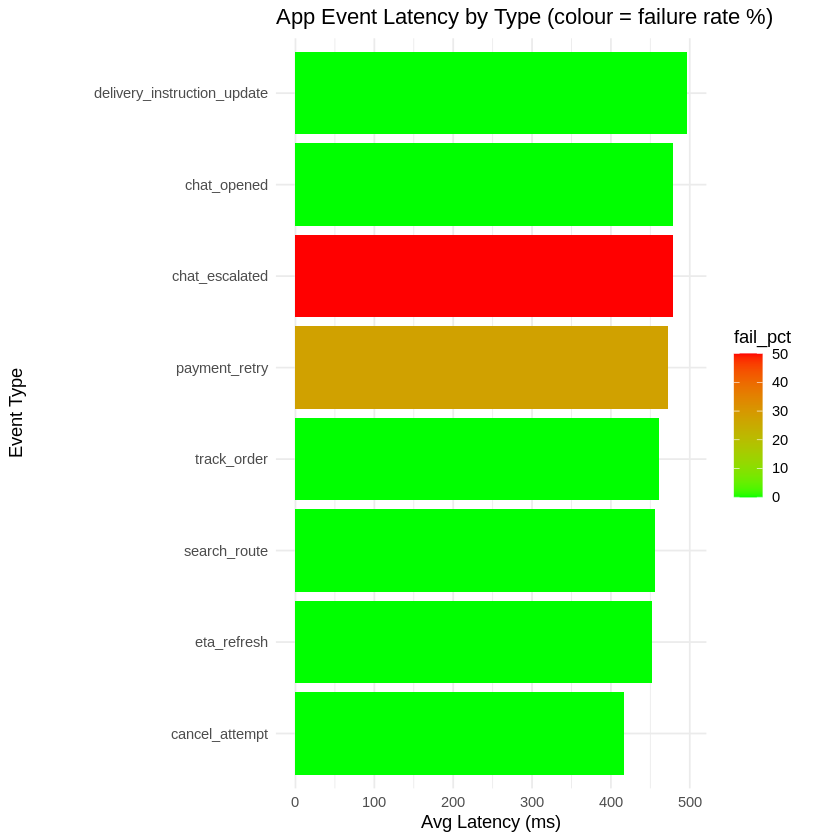

In [23]:
q16 <- dbGetQuery(con, "
  SELECT
    event_type,
    device_type,
    COUNT(*)                                        AS total_events,
    SUM(CASE WHEN success_flag=0 THEN 1 ELSE 0 END) AS failed_events,
    ROUND(AVG(api_latency_ms), 2)                   AS avg_latency_ms,
    ROUND(MAX(api_latency_ms), 2)                   AS max_latency_ms,
    ROUND(SUM(CASE WHEN success_flag=0
              THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 2) AS failure_rate_pct
  FROM app_events
  GROUP BY event_type, device_type
  ORDER BY failure_rate_pct DESC
")
print(q16)

q16_summary <- dbGetQuery(con, "
  SELECT event_type,
    ROUND(AVG(api_latency_ms),2) AS avg_latency,
    ROUND(SUM(CASE WHEN success_flag=0 THEN 1.0 ELSE 0 END)/COUNT(*)*100,2) AS fail_pct
  FROM app_events GROUP BY event_type ORDER BY avg_latency DESC
")
ggplot(q16_summary, aes(x=reorder(event_type, avg_latency),
                        y=avg_latency, fill=fail_pct)) +
  geom_bar(stat="identity") +
  coord_flip() +
  scale_fill_gradient(low="green", high="red") +
  labs(title="App Event Latency by Type (colour = failure rate %)",
       x="Event Type", y="Avg Latency (ms)") +
  theme_minimal()

       zone total_events avg_latency_ms max_latency_ms failed_events
1   AIRPORT           87         606.08           1701             4
2   CENTRAL           50         518.58           1558             4
3       CTR           43         489.35           1462             3
4     NORTH           93         444.28            944             7
5      EAST           91         434.71           1005             3
6     SOUTH           95         428.47            865             4
7      WEST           94         426.84           1074             5
8 RIVERSIDE           87         420.94           1138             8
  failure_rate_pct
1             4.60
2             8.00
3             6.98
4             7.53
5             3.30
6             4.21
7             5.32
8             9.20


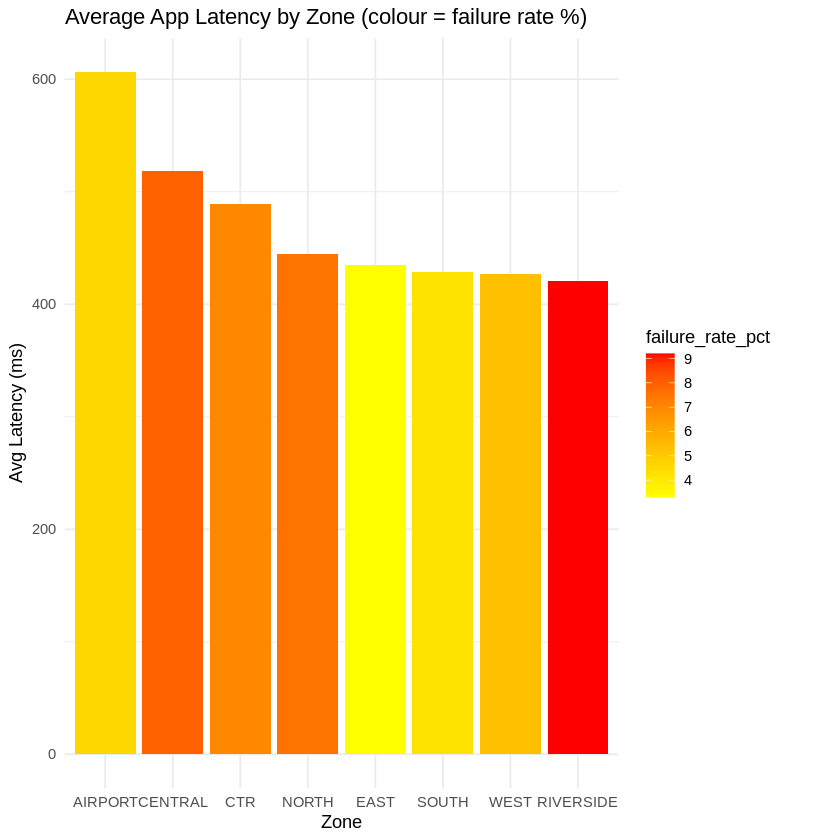

In [24]:
q17 <- dbGetQuery(con, "
  SELECT
    UPPER(zone_context)                             AS zone,
    COUNT(*)                                        AS total_events,
    ROUND(AVG(api_latency_ms), 2)                   AS avg_latency_ms,
    ROUND(MAX(api_latency_ms), 2)                   AS max_latency_ms,
    SUM(CASE WHEN success_flag=0 THEN 1 ELSE 0 END) AS failed_events,
    ROUND(SUM(CASE WHEN success_flag=0
              THEN 1.0 ELSE 0 END)/COUNT(*)*100, 2) AS failure_rate_pct
  FROM app_events
  GROUP BY UPPER(zone_context)
  ORDER BY avg_latency_ms DESC
")
print(q17)

ggplot(q17, aes(x=reorder(zone, -avg_latency_ms),
                y=avg_latency_ms, fill=failure_rate_pct)) +
  geom_bar(stat="identity") +
  scale_fill_gradient(low="yellow", high="red") +
  labs(title="Average App Latency by Zone (colour = failure rate %)",
       x="Zone", y="Avg Latency (ms)") +
  theme_minimal()

   customer_id customer_type home_zone loyalty_score total_orders
1        C0368      Consumer     North          49.5            3
2        C0110      Consumer      EAST            NA            3
3        C0282      Consumer RiverSide          71.4            2
4        C0372      Consumer      West          26.2            6
5        C0573           SME   AIRPORT          57.3            3
6        C0004      Consumer   CENTRAL          32.5            3
7        C0023      Consumer     South          73.1            6
8        C0032      Consumer      West          85.0            5
9        C0054      Consumer      WEST          42.4            4
10       C0056      Consumer     NORTH          71.1            2
11       C0178      Consumer      EAST          58.0            2
12       C0285      Consumer RiverSide          27.9            2
13       C0339      Consumer     SOUTH          46.6            3
14       C0351    Enterprise   CENTRAL          48.6            4
15       C

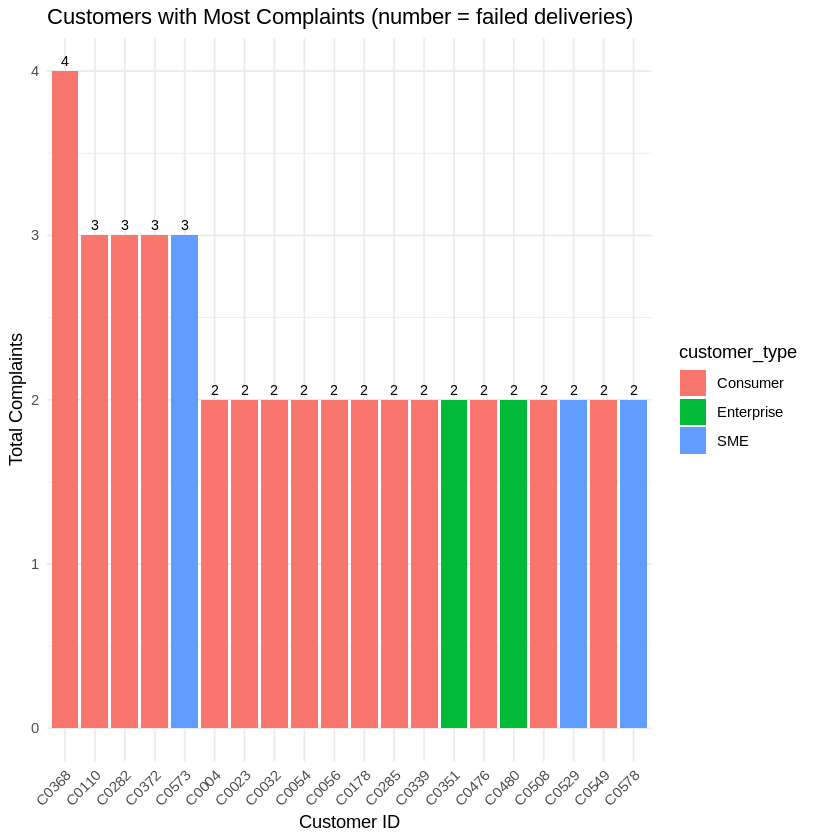

In [25]:
q18 <- dbGetQuery(con, "
  SELECT
    c.customer_id,
    c.customer_type,
    c.home_zone,
    c.loyalty_score,
    COUNT(DISTINCT o.order_id)                                     AS total_orders,
    COUNT(DISTINCT d.delivery_id)                                  AS total_deliveries,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed_deliveries,
    COUNT(DISTINCT cp.complaint_id)                                AS total_complaints,
    ROUND(AVG(cp.compensation_amount), 2)                          AS avg_compensation,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                 AS avg_rating
  FROM customers c
  LEFT JOIN orders     o  ON c.customer_id  = o.customer_id
  LEFT JOIN deliveries d  ON o.order_id     = d.order_id
  LEFT JOIN complaints cp ON c.customer_id  = cp.customer_id
  GROUP BY c.customer_id, c.customer_type,
           c.home_zone, c.loyalty_score
  HAVING failed_deliveries > 0 AND total_complaints > 0
  ORDER BY total_complaints DESC, failed_deliveries DESC
  LIMIT 20
")
print(q18)

ggplot(q18, aes(x=reorder(customer_id, -total_complaints),
                y=total_complaints, fill=customer_type)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=failed_deliveries), vjust=-0.5, size=3) +
  labs(title="Customers with Most Complaints (number = failed deliveries)",
       x="Customer ID", y="Total Complaints") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1))

         hub_name      zone employment_type total_deliveries missing_proofs
1     Airport Hub   Airport        Contract               12              2
2   Midtown Relay   Central        Contract               13              2
3     Airport Hub   Airport        PartTime               30              4
4       West Gate      West        Contract               15              2
5      South Link     South        PartTime               24              3
6    Central Core   Central        FullTime               63              7
7    Central Core   Central        Contract               19              2
8  North Exchange     North        Contract               19              2
9   Riverside Hub Riverside        FullTime               65              6
10      West Gate      West        PartTime               35              3
11      East Dock      East        FullTime               72              6
12     South Link     South        Contract               12              1
13  Midtown 

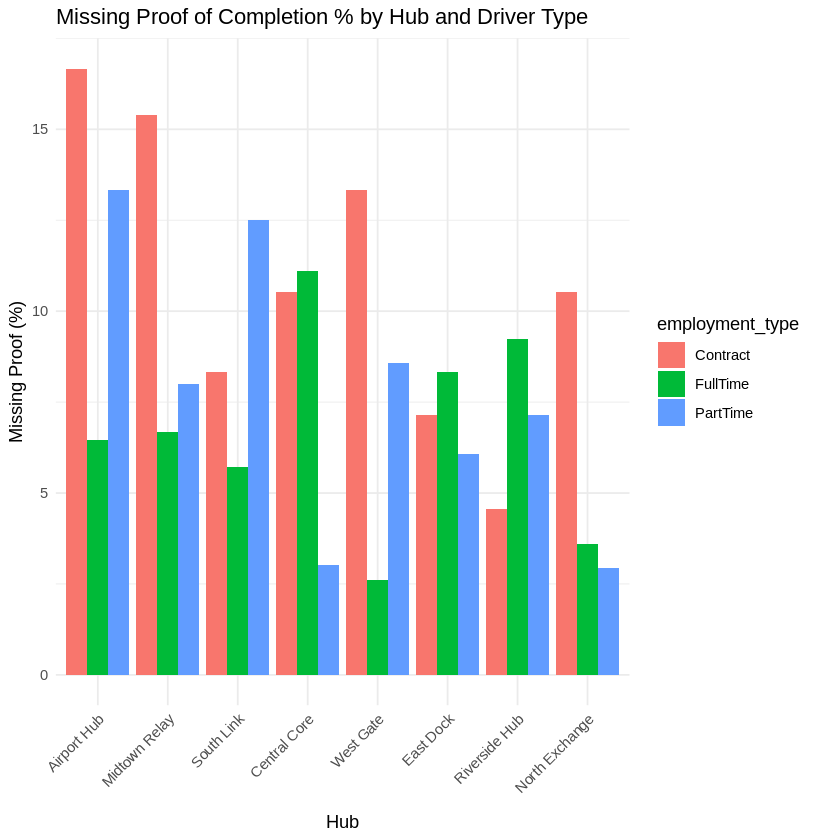

In [26]:
q19 <- dbGetQuery(con, "
  SELECT
    h.hub_name,
    h.zone,
    dr.employment_type,
    COUNT(d.delivery_id)                                           AS total_deliveries,
    SUM(d.proof_of_completion_missing)                             AS missing_proofs,
    ROUND(SUM(d.proof_of_completion_missing)*100.0/
          COUNT(d.delivery_id), 2)                                 AS missing_pct,
    SUM(CASE WHEN d.delivery_status='Failed'  THEN 1 ELSE 0 END)  AS failed
  FROM deliveries d
  JOIN hubs    h  ON d.hub_id    = h.hub_id
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY h.hub_name, h.zone, dr.employment_type
  HAVING missing_proofs > 0
  ORDER BY missing_pct DESC
")
print(q19)

ggplot(q19, aes(x=reorder(hub_name, -missing_pct),
                y=missing_pct, fill=employment_type)) +
  geom_bar(stat="identity", position="dodge") +
  labs(title="Missing Proof of Completion % by Hub and Driver Type",
       x="Hub", y="Missing Proof (%)") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1))

In [27]:
write.csv(q1,  "/content/q1_delivery_status_summary.csv",    row.names=FALSE)
write.csv(q2,  "/content/q2_hub_performance.csv",            row.names=FALSE)
write.csv(q3,  "/content/q3_service_type_performance.csv",   row.names=FALSE)
write.csv(q4,  "/content/q4_zone_performance.csv",           row.names=FALSE)
write.csv(q5,  "/content/q5_employment_type.csv",            row.names=FALSE)
write.csv(q6,  "/content/q6_training_vs_failure.csv",        row.names=FALSE)
write.csv(q7,  "/content/q7_route_overrides.csv",            row.names=FALSE)
write.csv(q8,  "/content/q8_vehicle_performance.csv",        row.names=FALSE)
write.csv(q9,  "/content/q9_battery_vs_incidents.csv",       row.names=FALSE)
write.csv(q10, "/content/q10_incident_resolution.csv",       row.names=FALSE)
write.csv(q11, "/content/q11_complaint_types.csv",           row.names=FALSE)
write.csv(q12, "/content/q12_customer_type_complaints.csv",  row.names=FALSE)
write.csv(q13, "/content/q13_loyalty_vs_complaints.csv",     row.names=FALSE)
write.csv(q14, "/content/q14_cost_by_service_zone.csv",      row.names=FALSE)
write.csv(q15, "/content/q15_priority_performance.csv",      row.names=FALSE)
write.csv(q16, "/content/q16_app_event_failures.csv",        row.names=FALSE)
write.csv(q17, "/content/q17_app_latency_by_zone.csv",       row.names=FALSE)
write.csv(q18, "/content/q18_customer_journey.csv",          row.names=FALSE)
write.csv(q19, "/content/q19_missing_proof.csv",             row.names=FALSE)

cat("All 19 query results saved successfully!\n")

All 19 query results saved successfully!
